In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from jaxtyping import Array, Float, Integer, Scalar, ScalarLike

import fairsim
from fairsim.model.mdp import (
    opt_choice_prob,
    opt_tpr,
    opt_unconstrained,
    transition,
    transition_kernel_construct,
)
from fairsim.util import tree_unstack

sns.set_theme(context='notebook', style='whitegrid')

In [ ]:
n_scores = 21
succ_prob = jnp.linspace(0.1, 0.9, n_scores)
init_distrib = (1 + jnp.arange(n_scores)) ** 4
init_distrib = init_distrib / init_distrib.sum()
reward = succ_prob - 0.72

kernel = transition_kernel_construct(
    repay=jnp.array([0, 0, 0, 1, 1, 1, 1]),
    default=jnp.array([4, 3, 2, 1, 0, 0, 0]),
    reject=jnp.array([0, 0, 0.01, 0.99, 0, 0, 0]),
    noise=jnp.array([1, 2, 1]),
)

distribs = (init_distrib, init_distrib[::-1])
n_iter = 3000
def sim_step(distribs, _):
    distribs_t = tuple(
        transition(
            distrib, opt_unconstrained(distrib, reward), succ_prob, kernel
        )
        for distrib in distribs
    )
    return distribs_t, distribs
distribs, history = jax.lax.scan(sim_step, distribs, None, length=n_iter + 1)
def dist(distribs):
    cdfs = jnp.array([distrib.cumsum() for distrib in distribs])
    return cdfs.ptp(axis=0).max()
dists = jax.vmap(dist)(history)

Text(0.5, 1.0, 'Distance between distributions over time')

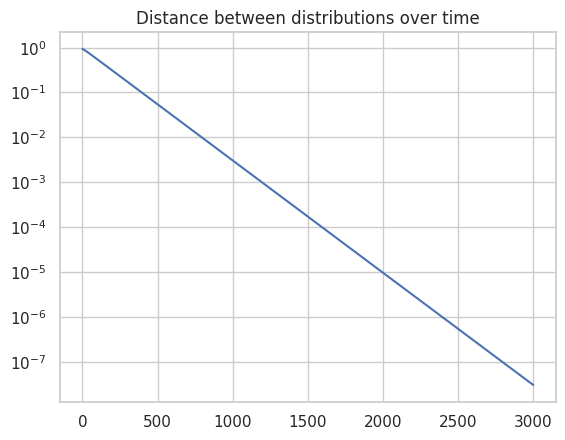

In [6]:
fig, ax = plt.subplots()
sns.lineplot(x=jnp.arange(len(dists)), y=dists, ax=ax)
ax.set_yscale('log')
ax.set_title("Distance between distributions over time")

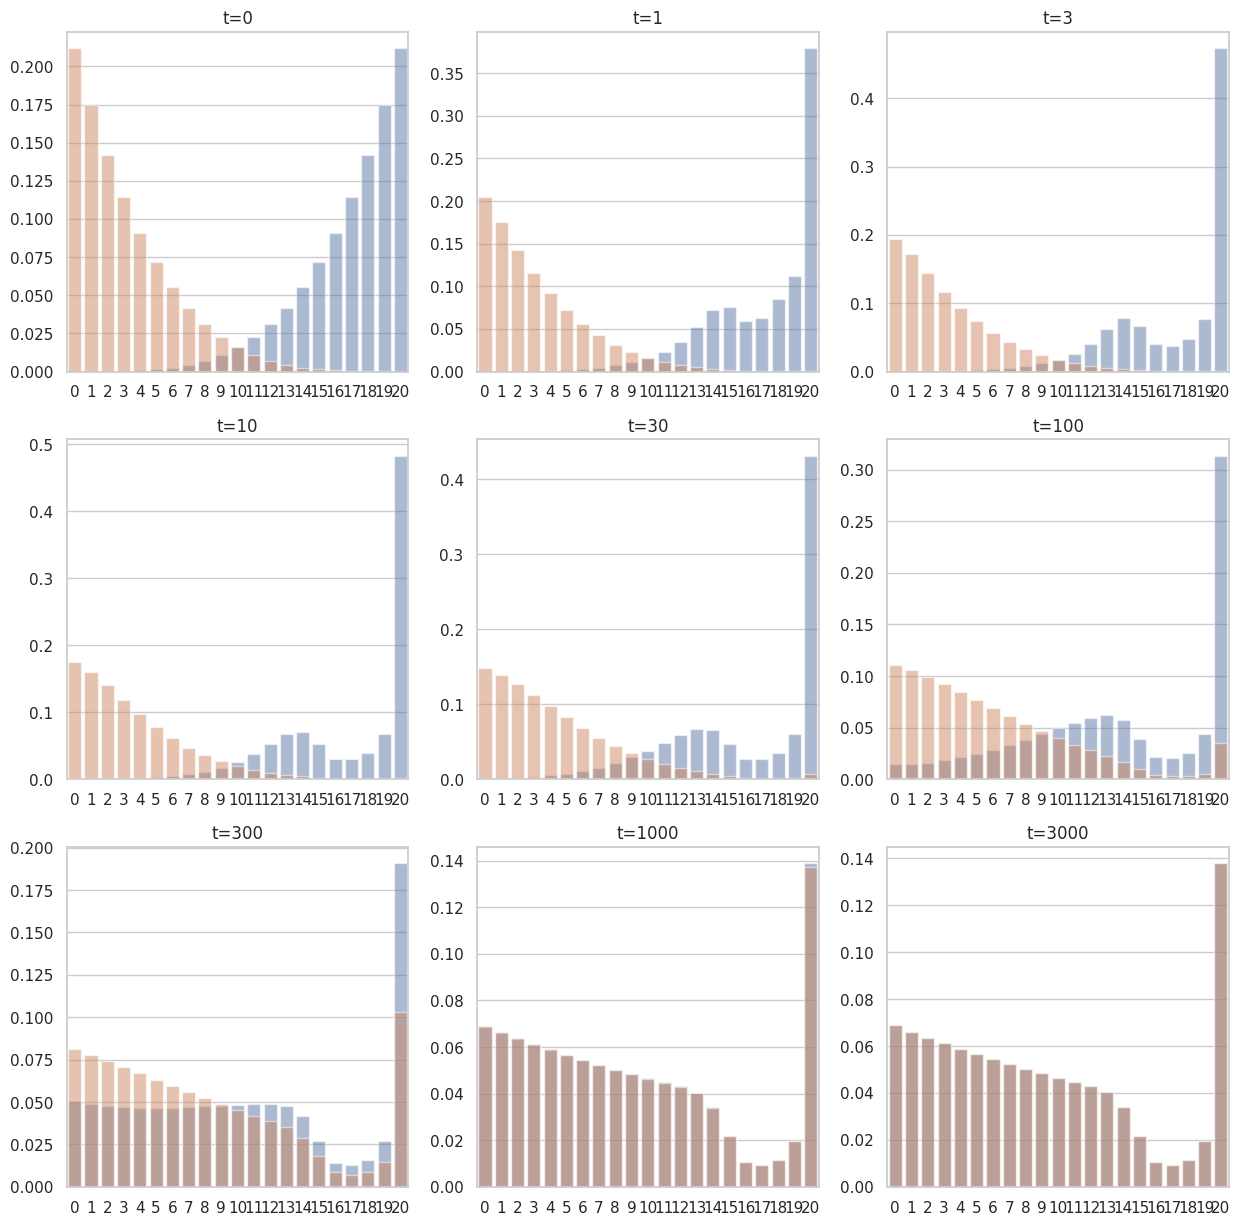

In [7]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

sampled_times = [0, 1, 3, 10, 30, 100, 300, 1000, 3000]
ht = list(tree_unstack(history))
for ax, t in zip(ax.flatten(), sampled_times):
    for distrib in ht[t]:
        sns.barplot(x=jnp.arange(n_scores), y=distrib, ax=ax, alpha=0.5)
        # sns.lineplot(x=jnp.arange(n_scores), y=distrib.cumsum(), ax=ax)
    ax.set_title(f"t={t}")